In [14]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

dataset = pd.read_csv('breast-cancer.csv')
dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [15]:
dataset.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

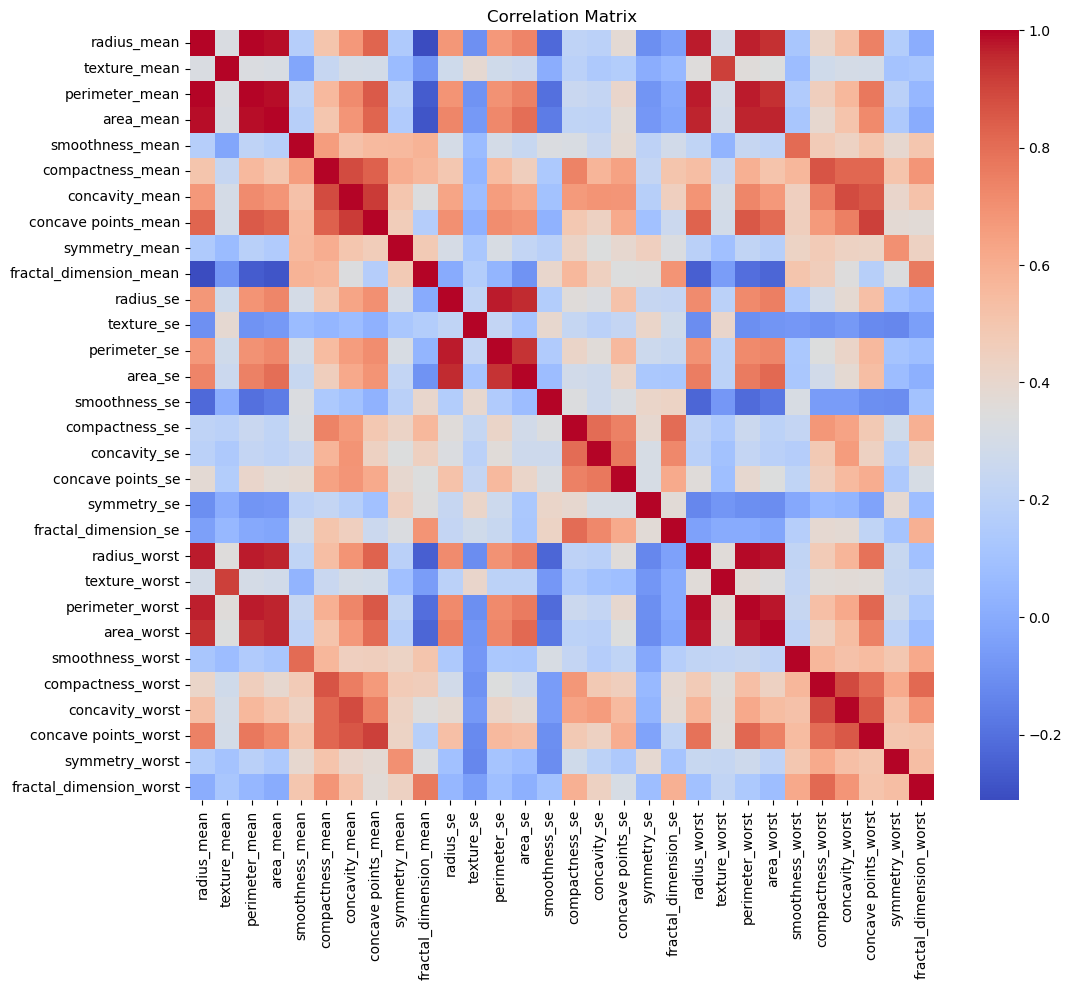

In [16]:
correlation = dataset.drop(columns=['id']).corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(correlation,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

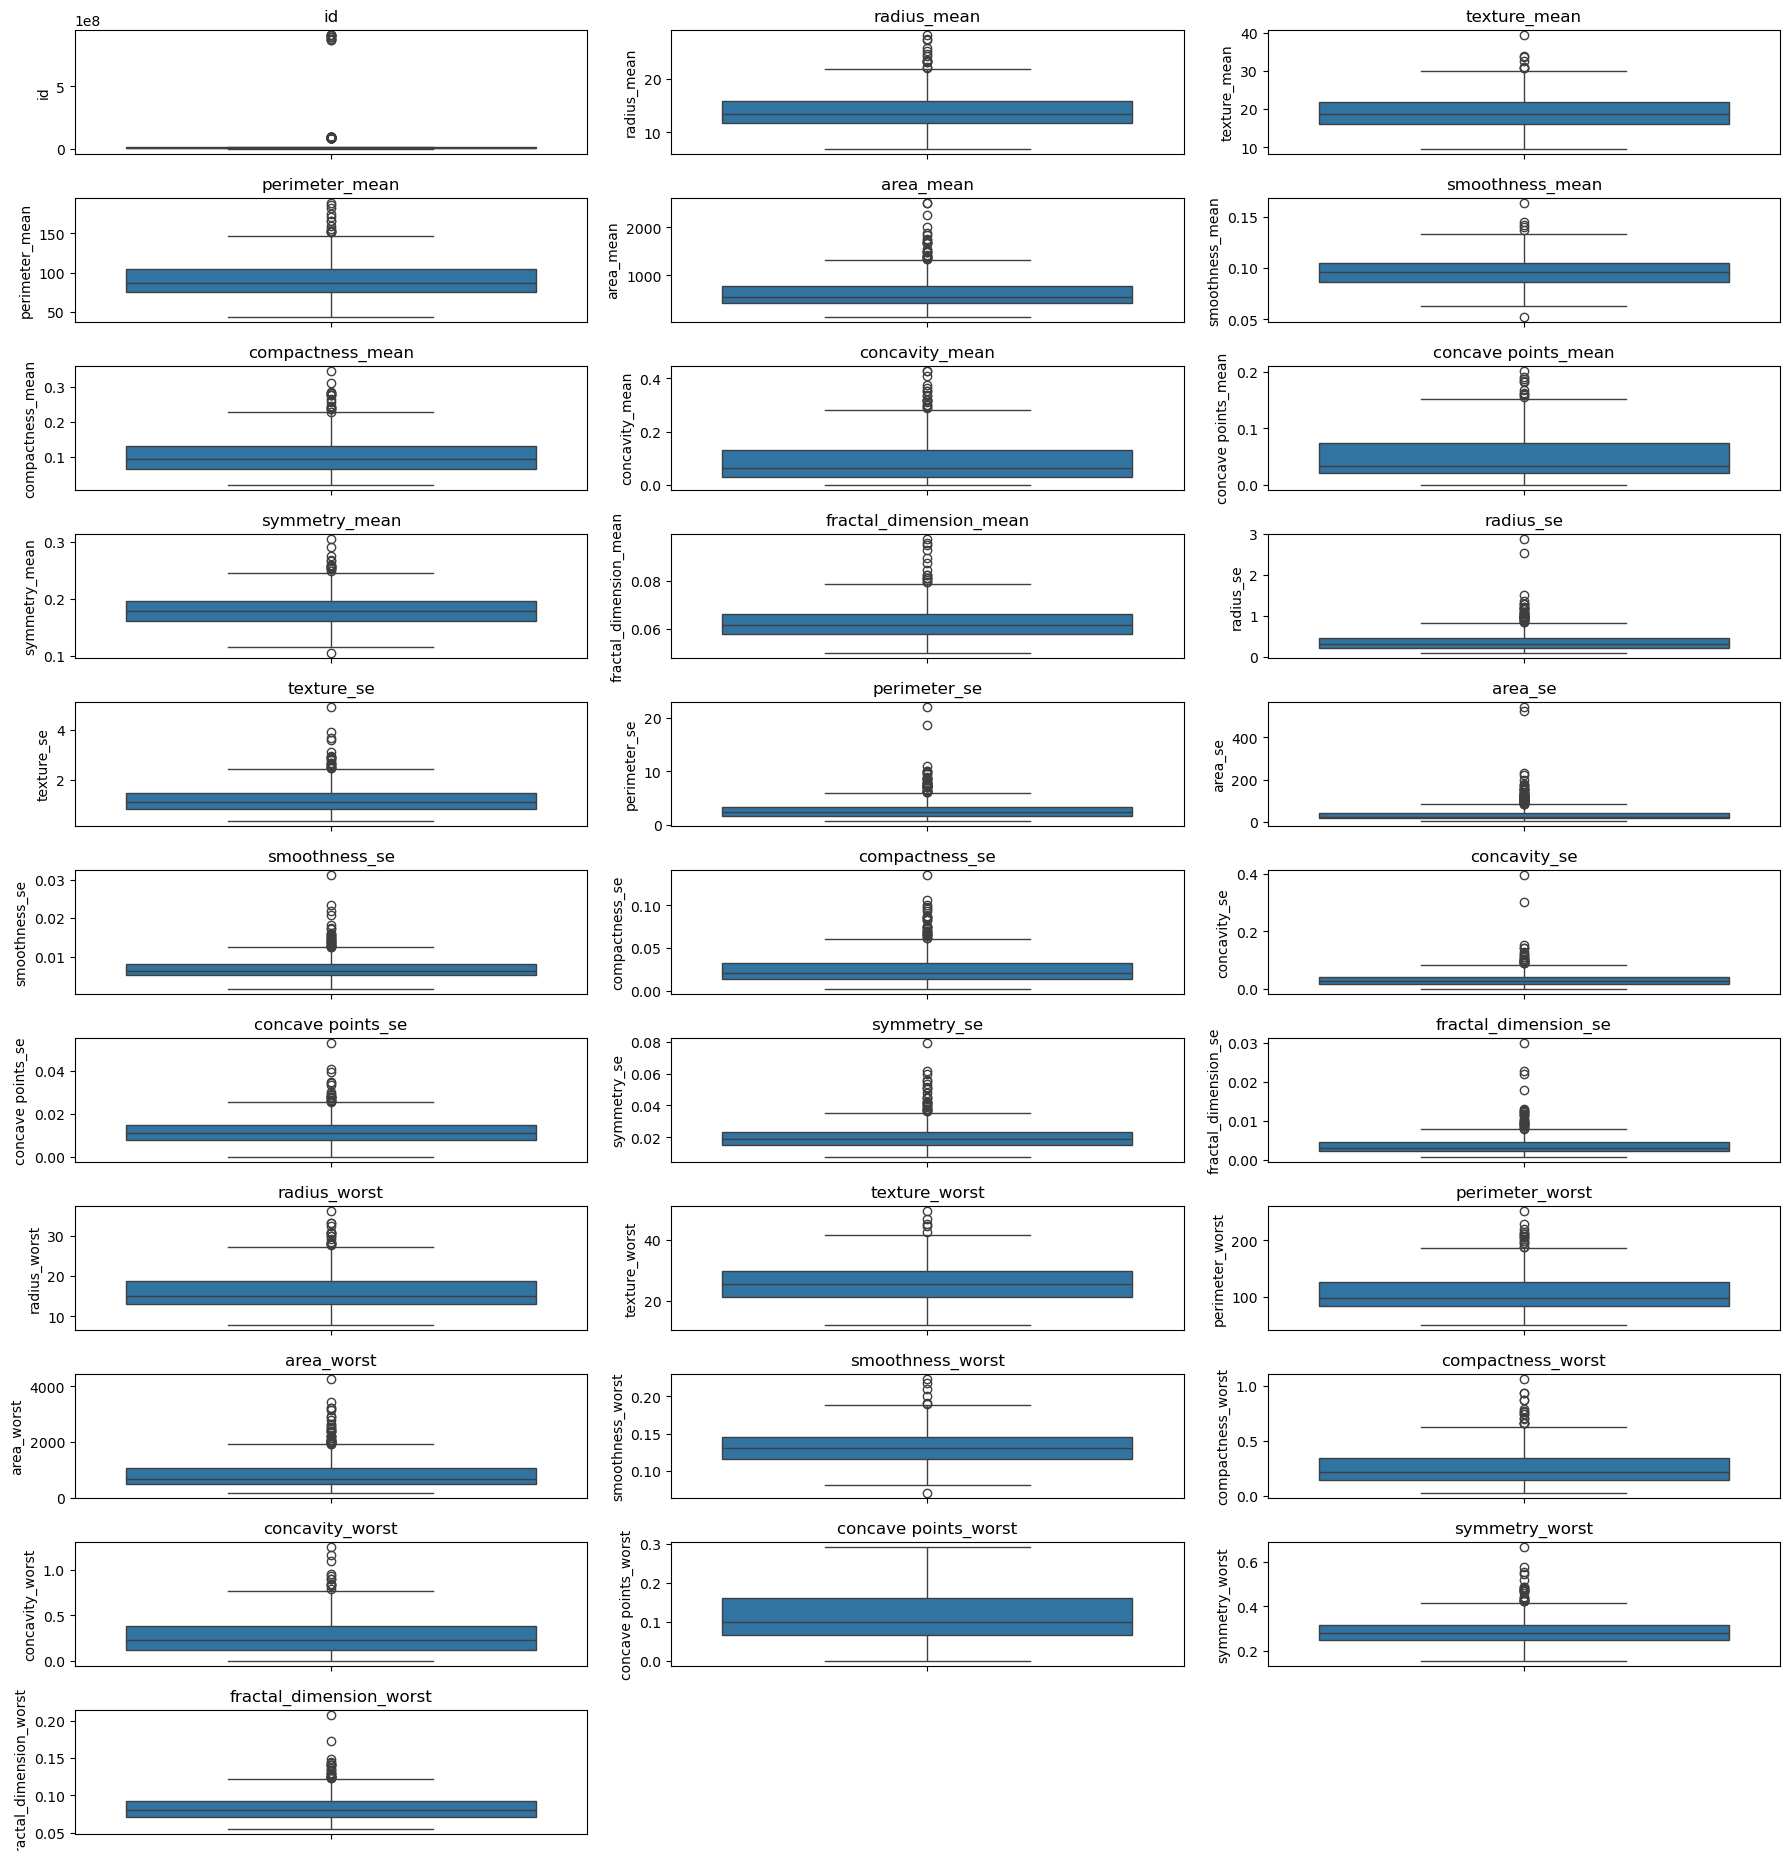

,Outlier Count
id,81
area_se,65
radius_se,38
perimeter_se,38
area_worst,35
smoothness_se,30
compactness_se,28
fractal_dimension_se,28
symmetry_se,27
area_mean,25


In [17]:
numeric_cols = dataset.select_dtypes(include=np.number).columns

plt.figure(figsize=(18, len(numeric_cols)*0.6))
for i,col in enumerate(numeric_cols,1):
    plt.subplot((len(numeric_cols)+2)//3,3,i)
    sns.boxplot(y=dataset[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Count outliers using IQR
outlier_counts={}
for col in numeric_cols:
    Q1=dataset[col].quantile(0.25)
    Q3=dataset[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outlier_counts[col]=((dataset[col]<lower)|(dataset[col]>upper)).sum()

pd.DataFrame.from_dict(outlier_counts,orient='index',columns=['Outlier Count']).sort_values('Outlier Count',ascending=False)


In [18]:
dataset_clean = dataset.copy()

numeric_cols = dataset_clean.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop('id')   

for col in numeric_cols:
    Q1 = dataset_clean[col].quantile(0.25)
    Q3 = dataset_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    dataset_clean[col] = dataset_clean[col].clip(lower, upper)

print("Outliers corrected successfully.")

Outliers corrected successfully.


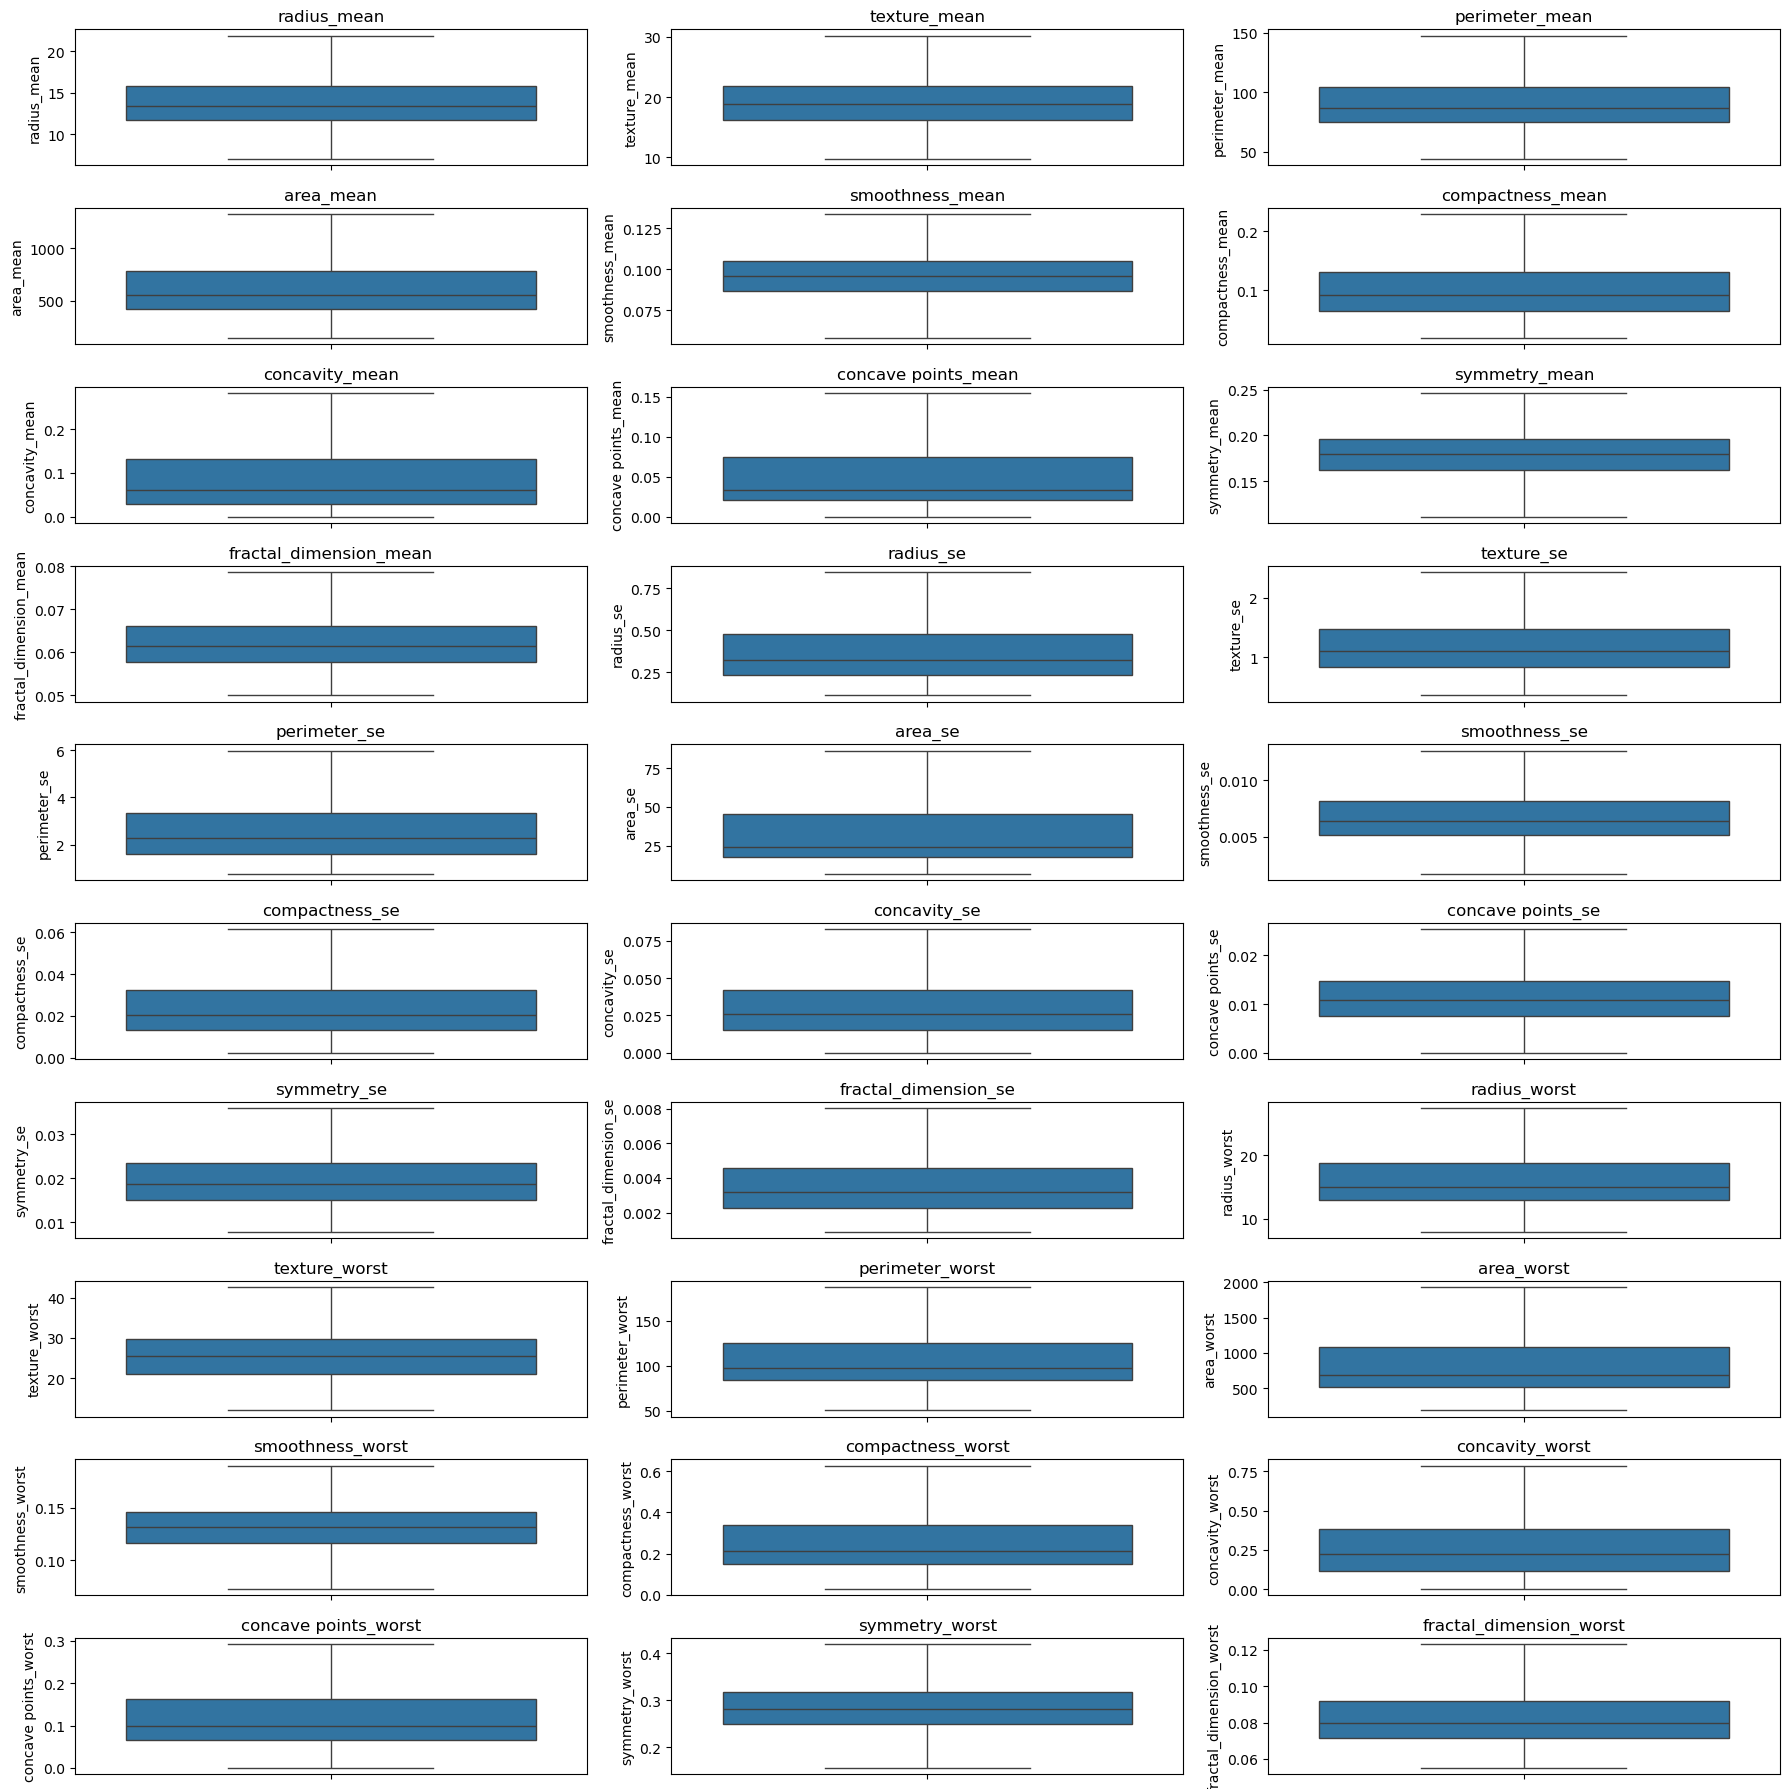

In [19]:
plt.figure(figsize=(18,18))

for i, col in enumerate(numeric_cols,1):
    plt.subplot((len(numeric_cols)+2)//3,3,i)
    sns.boxplot(y=dataset_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [20]:
encoder=LabelEncoder()
dataset['diagnosis']=encoder.fit_transform(dataset['diagnosis'])
print(dict(zip(encoder.classes_,encoder.transform(encoder.classes_))))

{'B': 0, 'M': 1}


In [21]:
x=dataset.drop(columns=['diagnosis'])
y=dataset['diagnosis']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=123)

model=LogisticRegression(max_iter=1000)
param_grid={'C':[0.01,0.1,1,10],'solver':['liblinear','lbfgs']}
grid=GridSearchCV(model,param_grid,cv=5,scoring='accuracy',n_jobs=-1)
grid.fit(x_train,y_train)
best_model=grid.best_estimator_
print(grid.best_params_)
print('Train:',accuracy_score(y_train,best_model.predict(x_train)))
print(classification_report(y_train,best_model.predict(x_train)))
print('Test:',accuracy_score(y_test,best_model.predict(x_test)))
print(classification_report(y_test,best_model.predict(x_test)))

{'C': 0.1, 'solver': 'lbfgs'}
Train: 0.9164835164835164
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       284
           1       0.92      0.85      0.88       171

    accuracy                           0.92       455
   macro avg       0.92      0.90      0.91       455
weighted avg       0.92      0.92      0.92       455

Test: 0.9385964912280702
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        73
           1       0.95      0.88      0.91        41

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



# Added Analysis
## Class Imbalance
- Visualize diagnosis distribution.
- Apply SMOTE after train/test split.

## PCA
Because the heatmap showed strong multicollinearity among radius, perimeter, and area features, PCA is applied after StandardScaler to reduce redundancy.

## Model Comparison
Compare Logistic Regression before PCA and after PCA+SMOTE.


In [ ]:

from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=dataset['diagnosis'])
plt.title('Diagnosis Class Distribution')
plt.show()

X=dataset.drop(columns=['diagnosis'])
y=dataset['diagnosis']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

sc=StandardScaler()
X_train_s=sc.fit_transform(X_train)
X_test_s=sc.transform(X_test)

sm=SMOTE(random_state=42)
X_sm,y_sm=sm.fit_resample(X_train_s,y_train)

sns.countplot(x=y_sm)
plt.title('Balanced Classes After SMOTE')
plt.show()

pca=PCA(n_components=0.95,random_state=42)
X_train_p=pca.fit_transform(X_sm)
X_test_p=pca.transform(X_test_s)

plt.figure(figsize=(8,4))
plt.plot(range(1,len(pca.explained_variance_ratio_)+1),pca.explained_variance_ratio_.cumsum(),marker='o')
plt.xlabel('Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

m1=LogisticRegression(max_iter=500)
m1.fit(X_sm,y_sm)
acc_before=accuracy_score(y_test,m1.predict(X_test_s))

m2=LogisticRegression(max_iter=500)
m2.fit(X_train_p,y_sm)
acc_after=accuracy_score(y_test,m2.predict(X_test_p))

print("Accuracy before PCA:",acc_before)
print("Accuracy after PCA:",acc_after)
